<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Katachi · Fine-tuning ResNet50 con etiqueta **Taylor**

**Objetivo.** Repetir el entrenamiento imagen-only del baseline de Katachi (ResNet50 pre-entrenada en Pipe3D), pero cambiando el *target* de $\log M_\star^{\text{Pipe3D}}$ (dex) a $\log M_\star^{\text{Taylor}}$ (dex).

**Sin mover arquitectura, transforms, optimizador ni splits.** Lo único que cambia entre el run de ayer (Pipe3D) y este notebook (Taylor) es la columna del target. Esto aísla el efecto de la etiqueta sobre la dispersión de los residuos.

**Unidades.** Todas las masas están en dex — $\log_{10}(M_\star / M_\odot)$. Los residuos, RMSE, MAE, $\sigma$, MAD y $\sigma_{\text{MAD}}$ se reportan también en dex.

**Diseño del experimento.**
1. Reconstruir la cohorte común de 8 494 galaxias con máscaras de calidad idénticas a las del notebook de comparación de masas.
2. Usar el split congelado Train/Val/Test = 6 510 / 1 149 / 835 (random_state = 42).
3. Cargar el checkpoint pre-entrenado de Katachi (`Mass_ResNet50_log_t50_chain_90_10.pytorch`) como punto de partida.
4. Evaluar ese checkpoint tal cual contra las etiquetas Taylor (baseline sin entrenar).
5. Fine-tuning con `target_col = "Taylor"`, Adam lr = 1e-4, MSELoss, batch 32, 20 épocas máx., early stopping por RMSE de Validation.
6. Reportar dispersión (RMSE, MAE, bias, σ, σ_MAD, Pearson, Spearman) en Validation y en Test.


## 1. Setup y reproducibilidad

Se fija una semilla base y se identifican las versiones principales del entorno para poder repetir el experimento tal cual en otra sesión de Colab.


In [1]:
# ============================================================
# 1 — SETUP
# ============================================================

import os
import sys
import random
import time
import copy
import json
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED_BASE = 42

def fijar_semilla(seed=SEED_BASE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

fijar_semilla()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python  :", sys.version.split()[0])
print("NumPy   :", np.__version__)
print("Pandas  :", pd.__version__)
print("Torch   :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
print("Device  :", device)


Python  : 3.13.15
NumPy   : 2.1.3
Pandas  : 2.2.3
Torch   : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA L4
Device  : cuda


In [2]:
# ============================================================
# 1.1 — INSTALAR HICKLE (formato de scalars.cat e images.cat)
# ============================================================

!pip install -q hickle

import hickle
print("hickle:", hickle.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 9.6 MB/s eta 0:00:00
hickle: 5.0.3


## 2. Carga de datos

Dos fuentes:

1. **`color_morp.csv`** (asesores) — trae `MANGAID`, `T_11`, `g_i`, `LogMassTaylor`, `LogMassNSA`. Se sube manualmente al entorno de Colab.
2. **`scalars.cat`** (repositorio oficial de Katachi) — trae `mangaid`, `log_mstar` (Pipe3D, dex) y `split` (Train / Test originales). Se descarga por `wget`.


In [3]:
# ============================================================
# 2.1 — SUBIR color_morp.csv
# ============================================================

from google.colab import files

print("Selecciona color_morp.csv desde tu máquina...")
uploaded = files.upload()

candidatos = [n for n in uploaded.keys() if n.lower().endswith(".csv")]
if not candidatos:
    raise FileNotFoundError("No se subió ningún CSV.")

# Preferir explícitamente color_morp.csv si está
preferidos = [n for n in candidatos if "color_morp" in n.lower()]
archivo_color_morp = preferidos[0] if preferidos else candidatos[0]

color_morp = pd.read_csv(archivo_color_morp)

print("Archivo cargado :", archivo_color_morp)
print("Filas           :", color_morp.shape[0])
print("Columnas        :", color_morp.columns.tolist())
display(color_morp.head())


Selecciona color_morp.csv desde tu máquina...


Saving color_morp.csv to color_morp.csv
Archivo cargado : color_morp.csv
Filas           : 10126
Columnas        : ['name', 'MANGAID', 'T_11', 'g_i', 'LogMassTaylor', 'LogMassNSA']


,name,MANGAID,T_11,g_i,LogMassTaylor,LogMassNSA
0,manga-10001-12701,1-48157,4,0.404967,9.269490,9.486857
1,manga-10001-12702,1-48188,4,0.644865,9.514213,9.727675
2,manga-10001-12703,1-55648,4,0.710236,9.944890,10.136514
3,manga-10001-12704,1-55616,7,0.766408,9.561902,9.632117
4,manga-10001-12705,1-55784,4,0.574194,9.977346,10.113519


In [4]:
# ============================================================
# 2.2 — VERIFICAR COLUMNAS NECESARIAS
# ============================================================

columnas_asesores = ["MANGAID", "T_11", "g_i",
                     "LogMassTaylor", "LogMassNSA"]

faltantes = [c for c in columnas_asesores if c not in color_morp.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en color_morp.csv: {faltantes}")

print("OK — todas las columnas necesarias están presentes.")
print(color_morp[columnas_asesores].dtypes)


OK — todas las columnas necesarias están presentes.
MANGAID           object
T_11               int64
g_i              float64
LogMassTaylor    float64
LogMassNSA       float64
dtype: object


In [5]:
# ============================================================
# 2.3 — DESCARGAR scalars.cat DE KATACHI
# ============================================================

import urllib.request

url_scalars = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/scalars.cat"
)

ruta_scalars = "/content/scalars.cat"

if not os.path.exists(ruta_scalars):
    print("Descargando scalars.cat...")
    urllib.request.urlretrieve(url_scalars, ruta_scalars)
else:
    print("scalars.cat ya existe en /content.")

print("Tamaño:", round(os.path.getsize(ruta_scalars) / 1024**2, 2), "MB")

scalars = hickle.load(ruta_scalars)

print("\n=== scalars.cat ===")
print("Tipo    :", type(scalars))
print("Shape   :", scalars.shape)
print("Columnas:", scalars.columns.tolist())
display(scalars[["mangaid", "log_mstar", "split"]].head())


Descargando scalars.cat...
Tamaño: 153.52 MB

=== scalars.cat ===
Tipo    : <class 'pandas.core.frame.DataFrame'>
Shape   : (10081, 30)
Columnas: ['mangaid', 'log_mstar', 'log_sfr', 'redshift', 'redshift_gz', 'sersic_n', 't50_Pipe3D', 't50_model', 'd4000', 'Av', 'Z', 'spirals', 'bars', 'irregular_features', 'edge_on', 'bulge', 'RA_Pipe3D', 'DEC_Pipe3D', 'RA_gz', 'DEC_gz', 'smooth', 'merger_gz', 'p_merger', 'over_density', 'z_completeness', 'split', 'pred_mstar', 'pred_sfr', 'pred_d4000', 'sfh']


,mangaid,log_mstar,split
0,1-1009,11.178438,Train
1,1-10166,11.513323,Train
2,1-10177,10.615028,Train
3,1-10263,9.305632,Train
4,1-1033,9.172108,Train


## 3. Máscaras de calidad

Se aplican los mismos criterios que el notebook de comparación de masas (viernes pasado):

- **Taylor válido**: `g_i` disponible, `g_i ≤ 2` y `LogMassTaylor` finita. El corte en `g_i ≤ 2` viene del asesor; se comprobó que elimina exclusivamente galaxias con colores irreales.
- **NSA disponible**: `LogMassNSA` finita.
- **Pipe3D disponible**: `log_mstar` finita.

Las máscaras se crean como columnas booleanas — no se eliminan filas todavía.


In [6]:
# ============================================================
# 3 — MÁSCARAS DE CALIDAD
# ============================================================

asesores_qc = color_morp.copy()
katachi_qc = scalars.copy()

# Normalizar MANGAID como string en ambas tablas
asesores_qc["MANGAID"] = asesores_qc["MANGAID"].astype(str).str.strip()
katachi_qc["mangaid"] = katachi_qc["mangaid"].astype(str).str.strip()

asesores_qc["Taylor_valido"] = (
    asesores_qc["g_i"].notna()
    & (asesores_qc["g_i"] <= 2)
    & np.isfinite(asesores_qc["LogMassTaylor"])
)

asesores_qc["NSA_disponible"] = np.isfinite(asesores_qc["LogMassNSA"])

katachi_qc["Pipe3D_disponible"] = np.isfinite(katachi_qc["log_mstar"])

print("Taylor válidas :", int(asesores_qc["Taylor_valido"].sum()))
print("NSA finitas    :", int(asesores_qc["NSA_disponible"].sum()))
print("Pipe3D finitas :", int(katachi_qc["Pipe3D_disponible"].sum()))


Taylor válidas : 8653
NSA finitas    : 10098
Pipe3D finitas : 10081


## 4. Merge y construcción de la cohorte común

Katachi es la tabla de referencia. Se hace un `left join` por `mangaid ↔ MANGAID` y se conserva solamente el subconjunto donde:

- `split ∈ {"Train", "Test"}` (galaxias que Katachi realmente usó);
- hay correspondencia en ambas tablas;
- Taylor, NSA y Pipe3D pasan sus máscaras de calidad.

Esa es exactamente la cohorte de 8 494 galaxias del notebook de comparación de masas. Como el corte es el mismo para las tres etiquetas, entrenar contra Pipe3D o contra Taylor se hace sobre **exactamente las mismas galaxias**.


In [7]:
# ============================================================
# 4 — COHORTE COMÚN
# ============================================================

columnas_asesores_merge = [
    "MANGAID", "T_11", "g_i",
    "LogMassTaylor", "LogMassNSA",
    "Taylor_valido", "NSA_disponible",
]

masas_cruzadas = katachi_qc.merge(
    asesores_qc[columnas_asesores_merge],
    how="left",
    left_on="mangaid",
    right_on="MANGAID",
    validate="one_to_one",
    indicator=True,
)

# Después del left-merge las flags de asesores pueden ser NaN
# (dtype object). fillna(False) las convierte a False de forma
# segura antes del AND.
mascara_comun = (
    masas_cruzadas["split"].isin(["Train", "Test"])
    & masas_cruzadas["_merge"].eq("both")
    & masas_cruzadas["Taylor_valido"].fillna(False).astype(bool)
    & masas_cruzadas["NSA_disponible"].fillna(False).astype(bool)
    & masas_cruzadas["Pipe3D_disponible"].fillna(False).astype(bool)
)

muestra_comun_masas = masas_cruzadas.loc[mascara_comun].copy()

# Renombrar columnas de masa para claridad
comparacion_masas = (
    muestra_comun_masas[["mangaid", "split",
                         "log_mstar", "LogMassTaylor", "LogMassNSA"]]
    .rename(columns={
        "log_mstar": "Pipe3D",
        "LogMassTaylor": "Taylor",
        "LogMassNSA": "NSA",
    })
    .reset_index(drop=True)
)

print("N cohorte común :", len(comparacion_masas))
print("Por split       :")
print(comparacion_masas["split"].value_counts())

assert comparacion_masas["mangaid"].duplicated().sum() == 0
assert len(comparacion_masas) == 8494, (
    f"Cohorte inesperada: {len(comparacion_masas)} != 8494"
)
print("\nOK — cohorte de 8 494 galaxias reconstruida.")


N cohorte común : 8494
Por split       :
split
Train    7659
Test      835
Name: count, dtype: int64

OK — cohorte de 8 494 galaxias reconstruida.


/tmp/ipykernel_1689/2140453132.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & masas_cruzadas["Taylor_valido"].fillna(False).astype(bool)
/tmp/ipykernel_1689/2140453132.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & masas_cruzadas["NSA_disponible"].fillna(False).astype(bool)


## 5. Split congelado Train / Validation / Test

- **Test** = Test original de Katachi (835 galaxias), reservado para la evaluación final.
- **Train interno / Validation** = split aleatorio 85 / 15 del Train original con `random_state = 42`, sin estratificar por target — así los tres experimentos (Pipe3D, Taylor, NSA) usan exactamente los mismos IDs.

Tamaños esperados: **6 510 / 1 149 / 835**.


In [8]:
# ============================================================
# 5 — SPLIT CONGELADO
# ============================================================

from sklearn.model_selection import train_test_split

datos_train_original = (
    comparacion_masas[comparacion_masas["split"] == "Train"]
    .sort_values("mangaid")
    .reset_index(drop=True)
)

datos_test = (
    comparacion_masas[comparacion_masas["split"] == "Test"]
    .sort_values("mangaid")
    .reset_index(drop=True)
)

ids_train_interno, ids_validation = train_test_split(
    datos_train_original["mangaid"].to_numpy(),
    test_size=0.15,
    random_state=SEED_BASE,
    shuffle=True,
)

ids_test = datos_test["mangaid"].to_numpy()

set_train = set(ids_train_interno)
set_val = set(ids_validation)
set_test = set(ids_test)

assert not (set_train & set_val)
assert not (set_train & set_test)
assert not (set_val & set_test)
assert len(set_train) + len(set_val) + len(set_test) == len(comparacion_masas)

tabla_splits = pd.concat([
    pd.DataFrame({"mangaid": sorted(set_train), "particion": "Train"}),
    pd.DataFrame({"mangaid": sorted(set_val),   "particion": "Validation"}),
    pd.DataFrame({"mangaid": sorted(set_test),  "particion": "Test"}),
], ignore_index=True)

print(tabla_splits["particion"].value_counts())

assert (tabla_splits["particion"].value_counts().to_dict()
        == {"Train": 6510, "Validation": 1149, "Test": 835})
print("\nOK — split 6510 / 1149 / 835 (idéntico al del notebook de comparación).")


particion
Train         6510
Validation    1149
Test           835
Name: count, dtype: int64

OK — split 6510 / 1149 / 835 (idéntico al del notebook de comparación).


## 6. Descarga y merge de `images.cat`

`images.cat` (~1.9 GB) contiene un `DataFrame` con columnas `mangaid` e `images`. Cada imagen es un `PIL.Image` RGB de 256×256 px, es decir la representación tal cual la usó Katachi para entrenar. No se le aplica ningún preprocesado adicional excepto `ToTensor()`, que escala los píxeles a [0, 1] — es exactamente el pipeline verificado en el notebook de comparación de masas.


In [9]:
# ============================================================
# 6 — images.cat
# ============================================================

url_images = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/images.cat"
)

ruta_images = "/content/images.cat"

if not os.path.exists(ruta_images):
    print("Descargando images.cat (~1.9 GB)...")
    urllib.request.urlretrieve(url_images, ruta_images)
else:
    print("images.cat ya existe en /content.")

print("Tamaño:", round(os.path.getsize(ruta_images) / 1024**2, 2), "MB")

images_cat = hickle.load(ruta_images)

print("\n=== images.cat ===")
print("Tipo    :", type(images_cat))
print("Shape   :", images_cat.shape)
print("Columnas:", images_cat.columns.tolist())

images_cat["mangaid"] = images_cat["mangaid"].astype(str).str.strip()
assert images_cat["mangaid"].duplicated().sum() == 0


Descargando images.cat (~1.9 GB)...
Tamaño: 1890.73 MB

=== images.cat ===
Tipo    : <class 'pandas.core.frame.DataFrame'>
Shape   : (10081, 2)
Columnas: ['mangaid', 'images']


In [10]:
# ============================================================
# 6.1 — MERGE cohorte ↔ imágenes
# ============================================================

datos_experimento = comparacion_masas.merge(
    images_cat[["mangaid", "images"]],
    how="left",
    on="mangaid",
    validate="one_to_one",
    indicator=True,
)

assert datos_experimento["_merge"].eq("both").all(), (
    "Hay galaxias de la cohorte sin imagen en images.cat."
)
datos_experimento = datos_experimento.drop(columns=["_merge"])

# Verificar formato de las imágenes
tamanos = datos_experimento["images"].apply(lambda im: im.size)
modos = datos_experimento["images"].apply(lambda im: im.mode)

assert (tamanos == (256, 256)).all()
assert (modos == "RGB").all()
print("OK — 8 494 imágenes RGB 256×256 alineadas por MANGAID.")

# Incorporar la partición congelada
datos_experimento = datos_experimento.merge(
    tabla_splits, on="mangaid", how="left", validate="one_to_one"
)
assert datos_experimento["particion"].isna().sum() == 0

# Ya no necesitamos la columna `split` (Train/Test de Katachi):
# `particion` es la única fuente de verdad ahora.
if "split" in datos_experimento.columns:
    datos_experimento = datos_experimento.drop(columns=["split"])

print("Distribución final por partición:")
print(datos_experimento["particion"].value_counts())


OK — 8 494 imágenes RGB 256×256 alineadas por MANGAID.
Distribución final por partición:
particion
Train         6510
Validation    1149
Test           835
Name: count, dtype: int64


## 7. Diagnóstico previo del target Taylor

Antes de entrenar, se compara la distribución de `Taylor` con la de `Pipe3D` sobre la **misma cohorte**. Esto es útil para interpretar el resultado: si la std intrínseca de `Taylor` es distinta a la de `Pipe3D`, el RMSE óptimo alcanzable también cambia — un modelo que solo predice la media tendría RMSE ≈ std del target.


,count,mean,median,std,min,max
Pipe3D,8494.0,10.5941,10.6239,0.6567,8.6828,16.3066
Taylor,8494.0,10.0341,10.0637,0.7569,8.0660,12.6157
NSA,8494.0,10.1414,10.1641,0.7023,5.9125,12.2974



Δ Taylor − Pipe3D (dex):
  N        : 8494
  bias     : -0.5600
  mediana  : -0.5493
  std      : 0.2258
  MAD      : 0.1184
  σ_MAD    : 0.1755


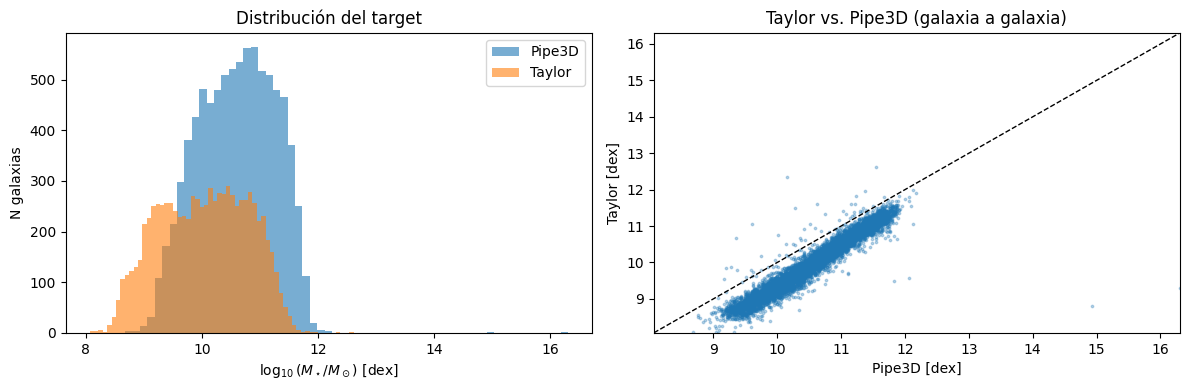

In [11]:
# ============================================================
# 7 — DISTRIBUCIÓN Taylor vs. Pipe3D (misma cohorte)
# ============================================================

resumen_targets = (
    comparacion_masas[["Pipe3D", "Taylor", "NSA"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
    .round(4)
)
display(resumen_targets)

delta = comparacion_masas["Taylor"] - comparacion_masas["Pipe3D"]
print("\nΔ Taylor − Pipe3D (dex):")
print(f"  N        : {len(delta)}")
print(f"  bias     : {delta.mean():.4f}")
print(f"  mediana  : {delta.median():.4f}")
print(f"  std      : {delta.std(ddof=1):.4f}")
print(f"  MAD      : {np.median(np.abs(delta - delta.median())):.4f}")
print(f"  σ_MAD    : {1.4826 * np.median(np.abs(delta - delta.median())):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(comparacion_masas["Pipe3D"], bins=60, alpha=0.6, label="Pipe3D")
ax[0].hist(comparacion_masas["Taylor"], bins=60, alpha=0.6, label="Taylor")
ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$ [dex]")
ax[0].set_ylabel("N galaxias")
ax[0].set_title("Distribución del target")
ax[0].legend()

ax[1].scatter(comparacion_masas["Pipe3D"], comparacion_masas["Taylor"],
              s=3, alpha=0.3)
lo = min(comparacion_masas["Pipe3D"].min(), comparacion_masas["Taylor"].min())
hi = max(comparacion_masas["Pipe3D"].max(), comparacion_masas["Taylor"].max())
ax[1].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[1].set_xlabel("Pipe3D [dex]")
ax[1].set_ylabel("Taylor [dex]")
ax[1].set_title("Taylor vs. Pipe3D (galaxia a galaxia)")
ax[1].set_xlim(lo, hi)
ax[1].set_ylim(lo, hi)

plt.tight_layout()
plt.show()


## 8. `Dataset` y `DataLoaders` para el target Taylor

El `Dataset` está parametrizado por `target_col`: exactamente el mismo objeto se puede usar mañana para Pipe3D o NSA cambiando una sola cadena. Aquí lo instanciamos con `"Taylor"`.

El único preprocesado es `ToTensor()` — coincide con el pipeline verificado en Katachi.


In [12]:
# ============================================================
# 8 — DATASET + DATALOADERS
# ============================================================

TARGET_COL = "Taylor"   # <-- ÚNICA VARIABLE ESPECÍFICA DEL EXPERIMENTO
BATCH_SIZE = 32          # idéntico al piloto de ayer

transform_katachi = transforms.Compose([
    transforms.ToTensor(),   # PIL RGB uint8 -> tensor float32 en [0, 1]
])


class KatachiMassDataset(Dataset):
    TARGETS_VALIDOS = {"Pipe3D", "Taylor", "NSA"}

    def __init__(self, dataframe, target_col, transform=None):
        if target_col not in self.TARGETS_VALIDOS:
            raise ValueError(
                f"target_col debe estar en {self.TARGETS_VALIDOS}"
            )
        self.df = dataframe.reset_index(drop=True)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]

        imagen = fila["images"]
        if self.transform is not None:
            imagen = self.transform(imagen)

        # Target escalar (dex). Batching produce shape [B].
        target = torch.tensor(
            float(fila[self.target_col]),
            dtype=torch.float32,
        )

        return {
            "image": imagen,
            "target": target,
            "mangaid": str(fila["mangaid"]),
        }


df_train = (datos_experimento[datos_experimento["particion"] == "Train"]
            .sort_values("mangaid").reset_index(drop=True))
df_val = (datos_experimento[datos_experimento["particion"] == "Validation"]
          .sort_values("mangaid").reset_index(drop=True))
df_test = (datos_experimento[datos_experimento["particion"] == "Test"]
           .sort_values("mangaid").reset_index(drop=True))

print("Train      :", len(df_train))
print("Validation :", len(df_val))
print("Test       :", len(df_test))

dataset_train = KatachiMassDataset(df_train, TARGET_COL, transform_katachi)
dataset_val = KatachiMassDataset(df_val, TARGET_COL, transform_katachi)
dataset_test = KatachiMassDataset(df_test, TARGET_COL, transform_katachi)

g_loader = torch.Generator()
g_loader.manual_seed(SEED_BASE)

# pin_memory acelera el transfer host->device en GPU y hace que
# `.to(..., non_blocking=True)` funcione realmente.
PIN = torch.cuda.is_available()

train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0,
                          pin_memory=PIN, generator=g_loader)
val_loader   = DataLoader(dataset_val,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          pin_memory=PIN)
test_loader  = DataLoader(dataset_test,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          pin_memory=PIN)

print("\nBatches: train =", len(train_loader),
      "| val =", len(val_loader),
      "| test =", len(test_loader))

# Sanity: inspeccionamos el Dataset directamente (NO llamamos
# iter(train_loader) porque eso consumiría el estado de g_loader
# y rompería la reproducibilidad del entrenamiento).
muestra = dataset_train[0]
print("\n=== MUESTRA DE SANITY ===")
print("image  :", muestra["image"].shape,  muestra["image"].dtype,
      "[", float(muestra["image"].min()), ",",
      float(muestra["image"].max()), "]")
print("target :", muestra["target"].shape, muestra["target"].dtype,
      float(muestra["target"]))
print("mangaid:", muestra["mangaid"])


Train      : 6510
Validation : 1149
Test       : 835

Batches: train = 204 | val = 36 | test = 27

=== MUESTRA DE SANITY ===
image  : torch.Size([3, 256, 256]) torch.float32 [ 0.0 , 0.9882352948188782 ]
target : torch.Size([]) torch.float32 10.537899017333984
mangaid: 1-1009


## 9. Modelo · ResNet50 + checkpoint pre-entrenado de Katachi

Arquitectura idéntica a la de ayer:

- `torchvision.models.resnet50` con `fc = nn.Linear(2048, 1)`.
- Se cargan los pesos de `Mass_ResNet50_log_t50_chain_90_10.pytorch` (entrenado por Katachi sobre Pipe3D). Se limpia el prefijo `module.` que introduce `DataParallel` y se carga con `strict=True`.

Ese checkpoint es el punto de partida tanto del run de Pipe3D (ayer) como de este run de Taylor: fijar el mismo estado inicial es necesario para que la comparación de dispersión sea justa.


In [13]:
# ============================================================
# 9 — DESCARGAR + CARGAR CHECKPOINT DE KATACHI
# ============================================================

url_ckpt = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/models/"
    "Mass_ResNet50_log_t50_chain_90_10.pytorch"
)

ruta_ckpt = "/content/Mass_ResNet50_log_t50_chain_90_10.pytorch"

if not os.path.exists(ruta_ckpt):
    print("Descargando checkpoint...")
    urllib.request.urlretrieve(url_ckpt, ruta_ckpt)
else:
    print("Checkpoint ya existe.")

print("Tamaño:", round(os.path.getsize(ruta_ckpt) / 1024**2, 2), "MB")

# weights_only=False es necesario porque el checkpoint fue guardado con
# un `OrderedDict` (torch.save antiguo). El default de PyTorch 2.6+ es
# `weights_only=True`, que rechaza ciertos tipos por seguridad. La
# fuente aquí es Katachi (Tohoku), oficial y confiable.
checkpoint = torch.load(ruta_ckpt, map_location="cpu", weights_only=False)

# Quitar el prefijo 'module.' de DataParallel
state_dict_limpio = OrderedDict(
    (k.replace("module.", ""), v) for k, v in checkpoint.items()
)

def construir_resnet50():
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(2048, 1)
    return m

model_base = construir_resnet50()
resultado = model_base.load_state_dict(state_dict_limpio, strict=True)
print("\nload_state_dict:", resultado)

# Sanity: forward con un tensor artificial
model_base.eval()
with torch.no_grad():
    salida = model_base(torch.randn(1, 3, 256, 256))
print("Forward de prueba OK. Salida shape:", salida.shape,
      "valor:", float(salida))


Descargando checkpoint...
Tamaño: 90.0 MB

load_state_dict: <All keys matched successfully>
Forward de prueba OK. Salida shape: torch.Size([1, 1]) valor: 26.745845794677734


## 10. Baseline · checkpoint pre-entrenado evaluado en las etiquetas Taylor

El checkpoint fue optimizado por Katachi contra Pipe3D. Al evaluarlo directamente contra Taylor obtenemos una **referencia de arranque**: cuánto se equivoca antes de hacer *cualquier* fine-tune sobre Taylor. Es el punto de partida contra el que se compara el modelo entrenado.


In [14]:
# ============================================================
# 10 — BASELINE EVAL EN VALIDATION
# ============================================================

def evaluar_modelo(model, loader, device):
    model = model.to(device)
    model.eval()

    ids, y_true, y_pred = [], [], []
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            targets = batch["target"].to(device, non_blocking=True)

            outputs = model(images).squeeze(-1)

            ids.extend(batch["mangaid"])
            y_true.extend(targets.detach().cpu().numpy().tolist())
            y_pred.extend(outputs.detach().cpu().numpy().tolist())

    return (
        np.asarray(ids),
        np.asarray(y_true, dtype=float),
        np.asarray(y_pred, dtype=float),
    )


def metricas_dispersion(y_true, y_pred, etiqueta):
    r = y_pred - y_true
    rmse = float(np.sqrt(np.mean(r ** 2)))
    mae = float(np.mean(np.abs(r)))
    bias = float(np.mean(r))
    std_res = float(np.std(r, ddof=1))
    mad = float(np.median(np.abs(r - np.median(r))))
    sigma_mad = 1.4826 * mad
    pearson = float(np.corrcoef(y_true, y_pred)[0, 1])
    # Spearman sin scipy: correlación de Pearson sobre rangos
    r_true = pd.Series(y_true).rank().to_numpy()
    r_pred = pd.Series(y_pred).rank().to_numpy()
    spearman = float(np.corrcoef(r_true, r_pred)[0, 1])

    return {
        "etiqueta": etiqueta,
        "N": int(len(y_true)),
        "RMSE_dex": rmse,
        "MAE_dex": mae,
        "bias_dex": bias,
        "sigma_residuos_dex": std_res,
        "MAD_dex": mad,
        "sigma_MAD_dex": sigma_mad,
        "pearson": pearson,
        "spearman": spearman,
    }


model_baseline = copy.deepcopy(model_base).to(device)

# Baseline en Validation
ids_val_base, y_val_true_base, y_val_pred_base = evaluar_modelo(
    model_baseline, val_loader, device
)
metricas_baseline_val = metricas_dispersion(
    y_val_true_base, y_val_pred_base,
    etiqueta="Pretrained-Pipe3D (sin fine-tune) · Val · Taylor labels",
)

# Baseline en Test (mismo modelo, sin haber tocado Test todavía
# para entrenar; esto es solo la lectura del checkpoint)
ids_test_base, y_test_true_base, y_test_pred_base = evaluar_modelo(
    model_baseline, test_loader, device
)
metricas_baseline_test = metricas_dispersion(
    y_test_true_base, y_test_pred_base,
    etiqueta="Pretrained-Pipe3D (sin fine-tune) · Test · Taylor labels",
)

print("=== BASELINE · Validation ===")
print(json.dumps(metricas_baseline_val, indent=2))
print("\n=== BASELINE · Test ===")
print(json.dumps(metricas_baseline_test, indent=2))

# Liberar RAM/VRAM del modelo de baseline
del model_baseline
if torch.cuda.is_available():
    torch.cuda.empty_cache()


=== BASELINE · Validation ===
{
  "etiqueta": "Pretrained-Pipe3D (sin fine-tune) \u00b7 Val \u00b7 Taylor labels",
  "N": 1149,
  "RMSE_dex": 0.605506962408385,
  "MAE_dex": 0.5408847757377657,
  "bias_dex": 0.5264222408191758,
  "sigma_residuos_dex": 0.2993263829239304,
  "MAD_dex": 0.18256282806396484,
  "sigma_MAD_dex": 0.2706676488876343,
  "pearson": 0.9325405606540051,
  "spearman": 0.9358137998712909
}

=== BASELINE · Test ===
{
  "etiqueta": "Pretrained-Pipe3D (sin fine-tune) \u00b7 Test \u00b7 Taylor labels",
  "N": 835,
  "RMSE_dex": 0.5838095163832411,
  "MAE_dex": 0.5233026218985369,
  "bias_dex": 0.5167540064828838,
  "sigma_residuos_dex": 0.2718222508020704,
  "MAD_dex": 0.1692056655883789,
  "sigma_MAD_dex": 0.25086431980133056,
  "pearson": 0.9361464476065612,
  "spearman": 0.9336850308882768
}


## 11. Fine-tuning contra el target Taylor

**Protocolo (idéntico al piloto imagen-only de ayer):**

- Punto de partida: `copy.deepcopy(model_base)` (checkpoint de Katachi).
- Optimizador: `Adam(lr = 1e-4)` sobre **todos** los parámetros.
- Pérdida: `MSELoss` en dex.
- Batch 32, sin scheduler.
- **20 épocas máximas** con *early stopping* sobre RMSE de Validation (paciencia 5). Al final se restaura el `state_dict` del mejor modelo por RMSE de Validation.

**Ojo con el sesgo de inicialización.** El checkpoint fue optimizado por Katachi para Pipe3D; para Taylor el modelo tiene que *desaprender* ese sesgo. Con early stopping y paciencia 5 esperamos alcanzar el plateau de Validation, pero si la curva no aplana claramente hay que correr más épocas o partir de pesos de ImageNet.

**Multi-semilla.** `SEEDS = [42]` corre una sola semilla. Cambiar a `[42, 7, 13]` (o similar) para tener una estimación de la variabilidad seed-to-seed. Se reporta el mejor modelo por RMSE de Validation entre todas las semillas.

Además de la RMSE 'sucia' calculada durante el forward pass en modo `.train()` (que va cambiando con las actualizaciones de peso y con BatchNorm en modo por-batch), después de cada época hacemos una **evaluación limpia sobre Train con `.eval()`** — esa es la que aparece como `rmse_train_dex`.


In [15]:
# ============================================================
# 11 — LOOP DE ENTRENAMIENTO (SOPORTA MULTI-SEED)
# ============================================================

EPOCHS = 20
PATIENCE = 5
LR = 1e-4
SEEDS = [SEED_BASE]   # <-- para multi-semilla: [42, 7, 13, ...]


def entrenar_una_semilla(seed_val):
    """
    Entrena una copia del modelo base con la semilla indicada.

    Devuelve (state_dict_cpu, historia_df, mejor_rmse_val, mejor_epoca).
    """
    # Determinismo: seed globales + seed del generador del DataLoader
    fijar_semilla(seed_val)
    g_loader.manual_seed(seed_val)

    model_iter = copy.deepcopy(model_base).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_iter.parameters(), lr=LR)

    historia = []
    mejor_rmse_val = float("inf")
    mejor_epoca = -1
    mejor_state = None
    epocas_sin_mejora = 0

    for epoca in range(1, EPOCHS + 1):
        t0 = time.time()

        # -------- TRAIN (backward pass) --------
        model_iter.train()
        losses_train = []
        for batch in train_loader:
            images = batch["image"].to(device, non_blocking=True)
            targets = batch["target"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model_iter(images).squeeze(-1)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            losses_train.append(loss.item())

        # -------- CLEAN EVAL SOBRE TRAIN (.eval()) --------
        _, y_tr_true, y_tr_pred = evaluar_modelo(model_iter, train_loader, device)
        rmse_train_clean = float(np.sqrt(np.mean((y_tr_pred - y_tr_true) ** 2)))

        # -------- CLEAN EVAL SOBRE VAL --------
        _, y_val_true, y_val_pred = evaluar_modelo(model_iter, val_loader, device)
        rmse_val = float(np.sqrt(np.mean((y_val_pred - y_val_true) ** 2)))
        mae_val = float(np.mean(np.abs(y_val_pred - y_val_true)))

        dt = time.time() - t0

        mejora = rmse_val < mejor_rmse_val - 1e-6
        if mejora:
            mejor_rmse_val = rmse_val
            mejor_epoca = epoca
            mejor_state = {k: v.detach().cpu().clone()
                           for k, v in model_iter.state_dict().items()}
            epocas_sin_mejora = 0
            marca = " *"
        else:
            epocas_sin_mejora += 1
            marca = ""

        historia.append({
            "seed": seed_val,
            "epoca": epoca,
            "loss_train_batch": float(np.mean(losses_train)),
            "rmse_train_dex": rmse_train_clean,
            "rmse_val_dex": rmse_val,
            "mae_val_dex": mae_val,
            "segundos": dt,
        })

        print(f"[seed={seed_val} E{epoca:02d}] "
              f"loss={np.mean(losses_train):.4f} "
              f"rmse_train={rmse_train_clean:.4f} "
              f"rmse_val={rmse_val:.4f} "
              f"mae_val={mae_val:.4f} "
              f"({dt/60:.1f} min){marca}")

        if epocas_sin_mejora >= PATIENCE:
            print(f"Early stopping en la época {epoca} "
                  f"(sin mejora en {PATIENCE} épocas).")
            break

    # Cleanup GPU antes de la siguiente semilla
    del model_iter, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return mejor_state, pd.DataFrame(historia), mejor_rmse_val, mejor_epoca


# ------------------------------------------------------------
# Correr todas las semillas
# ------------------------------------------------------------

resultados_por_semilla = []
for seed_val in SEEDS:
    print(f"\n{'=' * 60}\n=== SEMILLA {seed_val} ===\n{'=' * 60}")
    mejor_state, historia, mejor_rmse, mejor_ep = entrenar_una_semilla(seed_val)
    resultados_por_semilla.append({
        "seed": seed_val,
        "state_dict": mejor_state,
        "historia": historia,
        "mejor_rmse_val": mejor_rmse,
        "mejor_epoca": mejor_ep,
    })


# ------------------------------------------------------------
# Escoger la mejor semilla por RMSE de Validation
# ------------------------------------------------------------

idx_mejor = int(np.argmin([r["mejor_rmse_val"]
                           for r in resultados_por_semilla]))
resultado_mejor = resultados_por_semilla[idx_mejor]

print(f"\n{'=' * 60}")
print(f"Mejor semilla: {resultado_mejor['seed']} · "
      f"RMSE Val = {resultado_mejor['mejor_rmse_val']:.4f} dex · "
      f"época {resultado_mejor['mejor_epoca']}")

if len(SEEDS) > 1:
    rmses = np.array([r["mejor_rmse_val"] for r in resultados_por_semilla])
    print(f"\nVariabilidad entre semillas (RMSE Val, dex):")
    print(f"  media : {rmses.mean():.4f}")
    print(f"  std   : {rmses.std(ddof=1):.4f}")
    print(f"  min   : {rmses.min():.4f}")
    print(f"  max   : {rmses.max():.4f}")


# ------------------------------------------------------------
# Restaurar el mejor modelo global
# ------------------------------------------------------------

model = copy.deepcopy(model_base).to(device)
model.load_state_dict(resultado_mejor["state_dict"])

df_historial = pd.concat(
    [r["historia"] for r in resultados_por_semilla],
    ignore_index=True,
)
display(df_historial.round(4))



=== SEMILLA 42 ===
[seed=42 E01] loss=0.0815 rmse_train=0.3138 rmse_val=0.3364 mae_val=0.2580 (1.0 min) *
[seed=42 E02] loss=0.0752 rmse_train=0.2517 rmse_val=0.2816 mae_val=0.2043 (1.0 min) *
[seed=42 E03] loss=0.0714 rmse_train=0.2496 rmse_val=0.2770 mae_val=0.1990 (1.0 min) *
[seed=42 E04] loss=0.0692 rmse_train=0.2467 rmse_val=0.2861 mae_val=0.2102 (1.0 min)
[seed=42 E05] loss=0.0678 rmse_train=0.2758 rmse_val=0.3048 mae_val=0.2342 (1.0 min)
[seed=42 E06] loss=0.0685 rmse_train=0.2682 rmse_val=0.3000 mae_val=0.2225 (1.0 min)
[seed=42 E07] loss=0.0606 rmse_train=0.2464 rmse_val=0.2802 mae_val=0.2067 (1.0 min)
[seed=42 E08] loss=0.0648 rmse_train=0.3261 rmse_val=0.3619 mae_val=0.2947 (1.0 min)
Early stopping en la época 8 (sin mejora en 5 épocas).

Mejor semilla: 42 · RMSE Val = 0.2770 dex · época 3


,seed,epoca,loss_train_batch,rmse_train_dex,rmse_val_dex,mae_val_dex,segundos
0,42,1,0.0815,0.3138,0.3364,0.2580,60.5757
1,42,2,0.0752,0.2517,0.2816,0.2043,60.4053
2,42,3,0.0714,0.2496,0.2770,0.1990,60.5936
3,42,4,0.0692,0.2467,0.2861,0.2102,60.6589
4,42,5,0.0678,0.2758,0.3048,0.2342,60.5352
5,42,6,0.0685,0.2682,0.3000,0.2225,60.5855
6,42,7,0.0606,0.2464,0.2802,0.2067,60.6265
7,42,8,0.0648,0.3261,0.3619,0.2947,60.7460


## 12. Evaluación final · Validation y Test

Se evalúa el **mejor modelo por Validation RMSE** en las dos particiones. Test se toca una sola vez, al final, para el reporte.


In [16]:
# ============================================================
# 12 — EVAL FINAL
# ============================================================

ids_val, y_val_true, y_val_pred = evaluar_modelo(model, val_loader, device)
ids_test, y_test_true, y_test_pred = evaluar_modelo(model, test_loader, device)

metricas_val = metricas_dispersion(
    y_val_true, y_val_pred,
    etiqueta=f"Fine-tune Taylor · Val · seed={resultado_mejor['seed']}",
)
metricas_test = metricas_dispersion(
    y_test_true, y_test_pred,
    etiqueta=f"Fine-tune Taylor · Test · seed={resultado_mejor['seed']}",
)

tabla_metricas = pd.DataFrame([
    metricas_baseline_val,
    metricas_baseline_test,
    metricas_val,
    metricas_test,
])

print("\n=== MÉTRICAS DE DISPERSIÓN (dex) ===")
display(tabla_metricas.round(4))

# Deltas para hacer explícito el efecto del fine-tune
print("\n=== EFECTO DEL FINE-TUNE ===")
print(f"Val  · ΔRMSE = {metricas_val['RMSE_dex'] - metricas_baseline_val['RMSE_dex']:+.4f} dex")
print(f"Val  · Δσ_MAD = {metricas_val['sigma_MAD_dex'] - metricas_baseline_val['sigma_MAD_dex']:+.4f} dex")
print(f"Test · ΔRMSE = {metricas_test['RMSE_dex'] - metricas_baseline_test['RMSE_dex']:+.4f} dex")
print(f"Test · Δσ_MAD = {metricas_test['sigma_MAD_dex'] - metricas_baseline_test['sigma_MAD_dex']:+.4f} dex")



=== MÉTRICAS DE DISPERSIÓN (dex) ===


,etiqueta,N,RMSE_dex,MAE_dex,bias_dex,sigma_residuos_dex,MAD_dex,sigma_MAD_dex,pearson,spearman
0,Pretrained-Pipe3D (sin fine-tune) · Val · Tayl...,1149,0.6055,0.5409,0.5264,0.2993,0.1826,0.2707,0.9325,0.9358
1,Pretrained-Pipe3D (sin fine-tune) · Test · Tay...,835,0.5838,0.5233,0.5168,0.2718,0.1692,0.2509,0.9361,0.9337
2,Fine-tune Taylor · Val · seed=42,1149,0.2770,0.1990,0.0628,0.2699,0.1466,0.2173,0.9375,0.9404
3,Fine-tune Taylor · Test · seed=42,835,0.2583,0.1937,0.0702,0.2488,0.1452,0.2153,0.9389,0.9382



=== EFECTO DEL FINE-TUNE ===
Val  · ΔRMSE = -0.3285 dex
Val  · Δσ_MAD = -0.0533 dex
Test · ΔRMSE = -0.3255 dex
Test · Δσ_MAD = -0.0355 dex


## 13. Diagnósticos gráficos

Para cada partición: (a) predicho vs. verdadero, (b) histograma de residuos, (c) residuo vs. masa verdadera. La curva y = x en (a) y la línea horizontal en (c) marcan el modelo ideal.


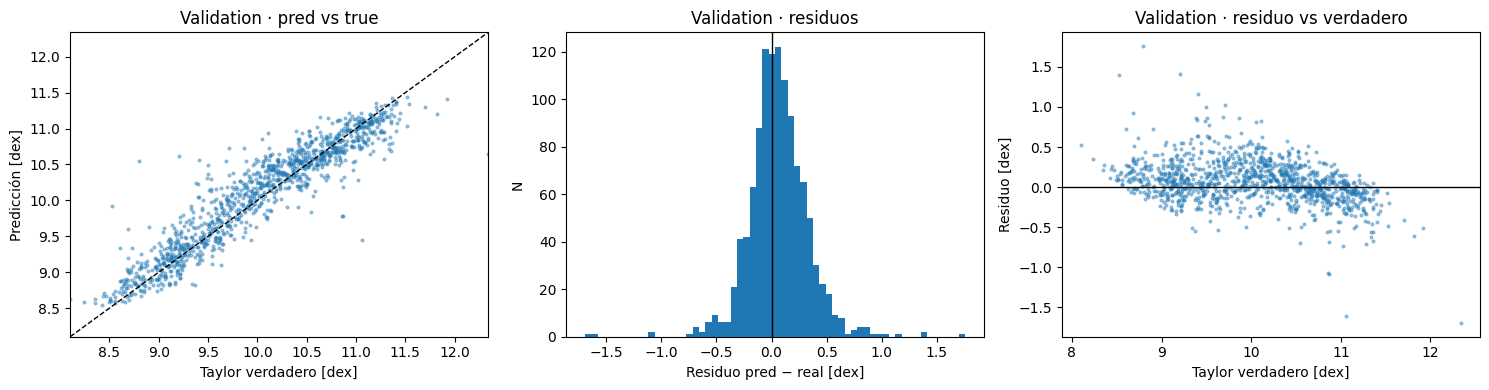

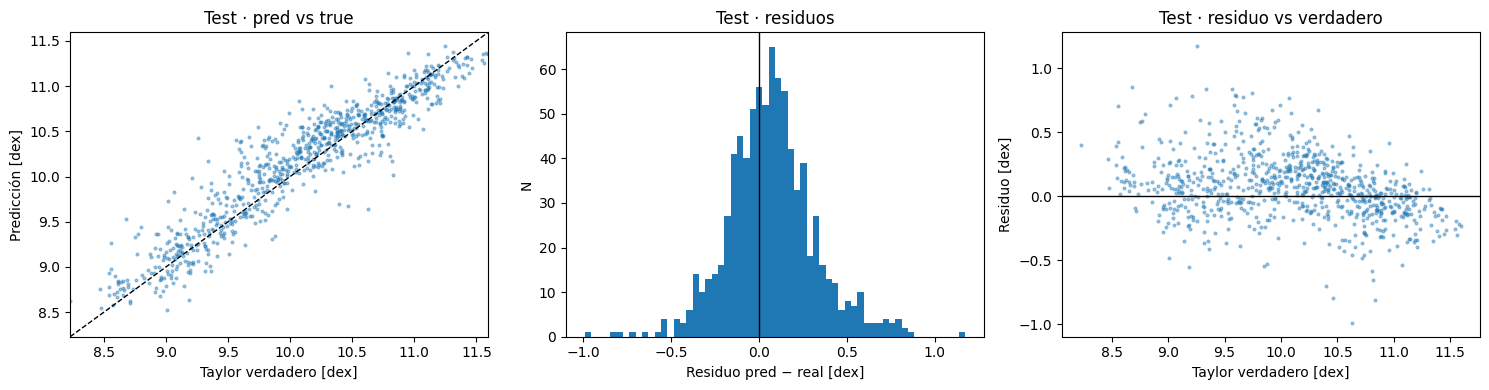

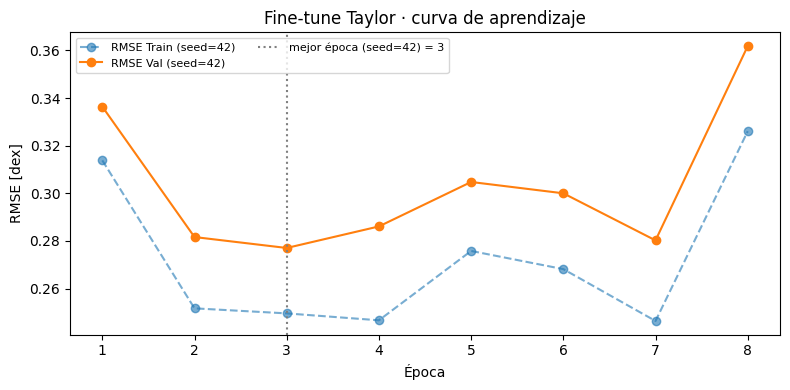

In [17]:
# ============================================================
# 13 — PLOTS
# ============================================================

def plots_diagnostico(y_true, y_pred, titulo):
    r = y_pred - y_true
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    ax[0].scatter(y_true, y_pred, s=4, alpha=0.4)
    ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
    ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)
    ax[0].set_xlabel("Taylor verdadero [dex]")
    ax[0].set_ylabel("Predicción [dex]")
    ax[0].set_title(f"{titulo} · pred vs true")

    ax[1].hist(r, bins=60)
    ax[1].axvline(0.0, color="k", lw=1)
    ax[1].set_xlabel("Residuo pred − real [dex]")
    ax[1].set_ylabel("N")
    ax[1].set_title(f"{titulo} · residuos")

    ax[2].scatter(y_true, r, s=4, alpha=0.4)
    ax[2].axhline(0.0, color="k", lw=1)
    ax[2].set_xlabel("Taylor verdadero [dex]")
    ax[2].set_ylabel("Residuo [dex]")
    ax[2].set_title(f"{titulo} · residuo vs verdadero")

    plt.tight_layout()
    plt.show()


plots_diagnostico(y_val_true, y_val_pred, "Validation")
plots_diagnostico(y_test_true, y_test_pred, "Test")

# Curvas de entrenamiento (una línea por semilla si hay varias)
fig, ax = plt.subplots(figsize=(8, 4))
for seed_val, sub in df_historial.groupby("seed"):
    label_tr = f"RMSE Train (seed={seed_val})"
    label_va = f"RMSE Val (seed={seed_val})"
    ax.plot(sub["epoca"], sub["rmse_train_dex"], "o--", alpha=0.6,
            label=label_tr)
    ax.plot(sub["epoca"], sub["rmse_val_dex"], "o-",
            label=label_va)
ax.axvline(resultado_mejor["mejor_epoca"], color="gray", ls=":",
           label=f"mejor época (seed={resultado_mejor['seed']}) = "
                 f"{resultado_mejor['mejor_epoca']}")
ax.set_xlabel("Época")
ax.set_ylabel("RMSE [dex]")
ax.set_title("Fine-tune Taylor · curva de aprendizaje")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 14. Guardar y descargar artefactos

Se persisten:

- `mejor_modelo_taylor.pt` — `state_dict` del mejor modelo por Validation.
- `predicciones_taylor_val.csv` y `predicciones_taylor_test.csv` — `mangaid`, target verdadero, predicción y residuo.
- `metricas_taylor.csv` — la tabla comparativa completa (baseline vs. fine-tune Val vs. fine-tune Test).
- `historial_entrenamiento_taylor.csv` — RMSE / MAE / loss por época.


In [18]:
# ============================================================
# 14 — ARTEFACTOS
# ============================================================

ruta_modelo = "/content/mejor_modelo_taylor.pt"
torch.save(model.state_dict(), ruta_modelo)

df_pred_val = pd.DataFrame({
    "mangaid": ids_val,
    "taylor_true_dex": y_val_true,
    "taylor_pred_dex": y_val_pred,
    "residuo_dex": y_val_pred - y_val_true,
})
df_pred_test = pd.DataFrame({
    "mangaid": ids_test,
    "taylor_true_dex": y_test_true,
    "taylor_pred_dex": y_test_pred,
    "residuo_dex": y_test_pred - y_test_true,
})

ruta_pred_val = "/content/predicciones_taylor_val.csv"
ruta_pred_test = "/content/predicciones_taylor_test.csv"
ruta_metricas = "/content/metricas_taylor.csv"
ruta_historial = "/content/historial_entrenamiento_taylor.csv"

df_pred_val.to_csv(ruta_pred_val, index=False)
df_pred_test.to_csv(ruta_pred_test, index=False)
tabla_metricas.to_csv(ruta_metricas, index=False)
df_historial.to_csv(ruta_historial, index=False)

for r in [ruta_modelo, ruta_pred_val, ruta_pred_test,
          ruta_metricas, ruta_historial]:
    print("Guardado:", r, "·",
          round(os.path.getsize(r) / 1024, 1), "KB")


Guardado: /content/mejor_modelo_taylor.pt · 92150.6 KB
Guardado: /content/predicciones_taylor_val.csv · 73.8 KB
Guardado: /content/predicciones_taylor_test.csv · 53.3 KB
Guardado: /content/metricas_taylor.csv · 0.9 KB
Guardado: /content/historial_entrenamiento_taylor.csv · 0.9 KB


In [19]:
# ============================================================
# 14.1 — DESCARGAR A LA MÁQUINA LOCAL
# ============================================================

from google.colab import files as colab_files

for ruta in [
    "/content/mejor_modelo_taylor.pt",
    "/content/predicciones_taylor_val.csv",
    "/content/predicciones_taylor_test.csv",
    "/content/metricas_taylor.csv",
    "/content/historial_entrenamiento_taylor.csv",
]:
    colab_files.download(ruta)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14.2 Comparación cruzada Pipe3D · Taylor · NSA (opcional)

Esta es la sección que responde directamente al asesor. Sube **cualquiera** de los siguientes archivos si ya los tienes:

- `metricas_pipe3d.csv` (versión Pipe3D de este mismo notebook).
- `metricas_nsa.csv` (versión NSA).

Si todavía no existen, corre esta celda igualmente — solo se mostrará la fila de Taylor. Cuando termines los otros dos runs, vuelve, sube los archivos y regenera la tabla y la gráfica.


Sube metricas_pipe3d.csv y/o metricas_nsa.csv si los tienes.
Si no, presiona Cancel — la tabla se genera solo con Taylor.



=== TABLA COMPARATIVA (todos los targets disponibles) ===


,etiqueta,N,RMSE_dex,MAE_dex,bias_dex,sigma_residuos_dex,MAD_dex,sigma_MAD_dex,pearson,spearman
0,Pretrained-Pipe3D (sin fine-tune) · Val · Tayl...,1149,0.6055,0.5409,0.5264,0.2993,0.1826,0.2707,0.9325,0.9358
1,Pretrained-Pipe3D (sin fine-tune) · Test · Tay...,835,0.5838,0.5233,0.5168,0.2718,0.1692,0.2509,0.9361,0.9337
2,Fine-tune Taylor · Val · seed=42,1149,0.2770,0.1990,0.0628,0.2699,0.1466,0.2173,0.9375,0.9404
3,Fine-tune Taylor · Test · seed=42,835,0.2583,0.1937,0.0702,0.2488,0.1452,0.2153,0.9389,0.9382



Guardado: /content/metricas_cross_target.csv


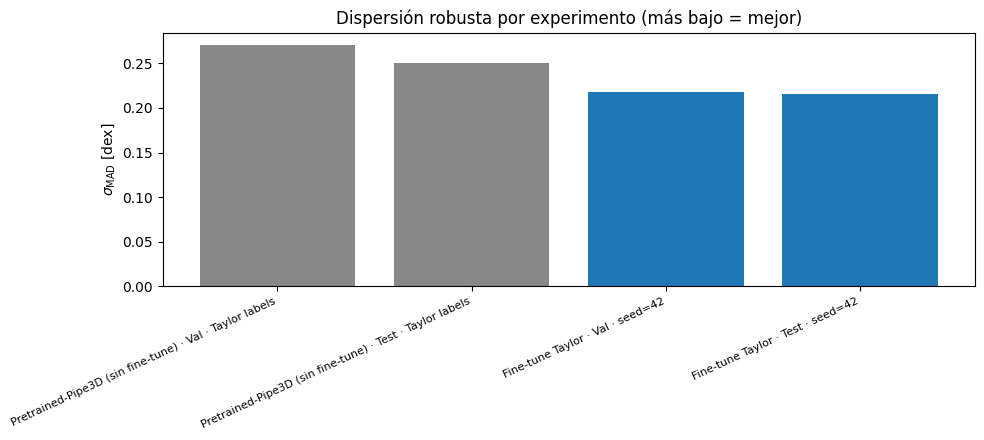

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# ============================================================
# 14.2 — COMPARACIÓN CRUZADA Pipe3D / Taylor / NSA
# ============================================================

print("Sube metricas_pipe3d.csv y/o metricas_nsa.csv si los tienes.")
print("Si no, presiona Cancel — la tabla se genera solo con Taylor.")

try:
    subidos_cross = colab_files.upload()
except Exception as exc:
    print("Upload cancelado:", exc)
    subidos_cross = {}

otros_dfs = []
for nombre, blob in subidos_cross.items():
    if not nombre.lower().endswith(".csv"):
        continue
    destino = f"/content/{nombre}"
    with open(destino, "wb") as f:
        f.write(blob)
    try:
        df_ot = pd.read_csv(destino)
        # Validar que trae las columnas esperadas
        columnas_esperadas = {"etiqueta", "N", "RMSE_dex", "MAE_dex",
                              "bias_dex", "sigma_MAD_dex"}
        if columnas_esperadas.issubset(df_ot.columns):
            otros_dfs.append(df_ot)
            print(f"OK — cargado {nombre} ({len(df_ot)} filas).")
        else:
            faltan = columnas_esperadas - set(df_ot.columns)
            print(f"IGNORADO — a {nombre} le faltan columnas: {faltan}")
    except Exception as e:
        print(f"IGNORADO — no se pudo leer {nombre}: {e}")

if otros_dfs:
    tabla_cross = pd.concat([tabla_metricas] + otros_dfs, ignore_index=True)
else:
    tabla_cross = tabla_metricas.copy()

# Persistir la tabla cruzada
ruta_cross = "/content/metricas_cross_target.csv"
tabla_cross.to_csv(ruta_cross, index=False)

print("\n=== TABLA COMPARATIVA (todos los targets disponibles) ===")
display(tabla_cross.round(4))
print(f"\nGuardado: {ruta_cross}")


# --- Gráfica de dispersión σ_MAD por experimento ---
if len(tabla_cross) >= 2:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    xs = np.arange(len(tabla_cross))
    # Coloreamos baseline vs fine-tune para leer más rápido
    colores = ["#888888" if "sin fine-tune" in e.lower()
               else "#1f77b4" for e in tabla_cross["etiqueta"]]
    ax.bar(xs, tabla_cross["sigma_MAD_dex"], color=colores)
    ax.set_xticks(xs)
    ax.set_xticklabels(tabla_cross["etiqueta"], rotation=25,
                       ha="right", fontsize=8)
    ax.set_ylabel(r"$\sigma_{\rm MAD}$ [dex]")
    ax.set_title("Dispersión robusta por experimento (más bajo = mejor)")
    plt.tight_layout()
    plt.show()

    # Ofrecer la descarga si el usuario quiere el CSV cruzado
    try:
        colab_files.download(ruta_cross)
    except Exception:
        pass


## 16. Análisis automático de resultados

Esta sección se apoya en las predicciones que quedaron en memoria (`y_val_true/pred`, `y_test_true/pred`) y calcula:

1. **Métricas centrales de dispersión** por partición.
2. **Pendiente de residuo vs. masa verdadera** — mide *regression-to-the-mean* (el sesgo clásico de un regresor MSE que comprime hacia la media).
3. **Fracción de outliers** ($|r - \tilde{r}| > 2\sigma_{\rm MAD}$ y $> 3\sigma_{\rm MAD}$).
4. **Residuos por bin de masa** — revela si el modelo se equivoca sistemáticamente en un régimen específico.
5. **Efecto del fine-tune** — mejora relativa vs. baseline en RMSE y $\sigma_{\rm MAD}$.

La celda produce números; la interpretación específica del run (qué significan para el asesor) queda en la sección 16.2 abajo.


In [ ]:
# ============================================================
# 16.1 — REPORTE AUTOMÁTICO
# ============================================================

def analizar_predicciones(nombre, y_true, y_pred, baseline_row=None):
    """Imprime un bloque de diagnóstico completo para una partición."""
    r = y_pred - y_true
    med = np.median(r)
    sigma_mad = 1.4826 * np.median(np.abs(r - med))

    slope, intercept = np.polyfit(y_true, r, 1)
    n_out2 = int(np.sum(np.abs(r - med) > 2 * sigma_mad))
    n_out3 = int(np.sum(np.abs(r - med) > 3 * sigma_mad))

    print(f"=== {nombre} ===")
    print(f"  N galaxias                : {len(y_true)}")
    print(f"  RMSE                      : {np.sqrt(np.mean(r**2)):.4f} dex")
    print(f"  MAE                       : {np.mean(np.abs(r)):.4f} dex")
    print(f"  Bias medio                : {np.mean(r):+.4f} dex")
    print(f"  Bias mediana              : {np.median(r):+.4f} dex")
    print(f"  σ residuos                : {np.std(r, ddof=1):.4f} dex")
    print(f"  σ_MAD                     : {sigma_mad:.4f} dex")
    print(f"  Pearson y_pred vs y_true  : {np.corrcoef(y_true, y_pred)[0,1]:.4f}")
    print(f"  Pendiente r vs y_true     : {slope:+.4f} dex/dex")
    print(f"    (|slope| < 0.05 = sin regression-to-mean;")
    print(f"     0.05-0.15 = suave; > 0.15 = fuerte)")
    print(f"  Outliers |r-med|>2σ_MAD   : {n_out2} ({100*n_out2/len(r):.2f}%)")
    print(f"  Outliers |r-med|>3σ_MAD   : {n_out3} ({100*n_out3/len(r):.2f}%)")

    if baseline_row is not None:
        rmse = float(np.sqrt(np.mean(r**2)))
        d_rmse = rmse - baseline_row["RMSE_dex"]
        d_smad = sigma_mad - baseline_row["sigma_MAD_dex"]
        print(f"  ΔRMSE vs baseline         : {d_rmse:+.4f} dex "
              f"({100*d_rmse/baseline_row['RMSE_dex']:+.1f}%)")
        print(f"  Δσ_MAD vs baseline        : {d_smad:+.4f} dex "
              f"({100*d_smad/baseline_row['sigma_MAD_dex']:+.1f}%)")

    return {
        "slope": slope, "intercept": intercept,
        "sigma_mad": sigma_mad,
        "n_out2": n_out2, "n_out3": n_out3,
    }


stats_val = analizar_predicciones(
    "VALIDATION · fine-tune",
    y_val_true, y_val_pred,
    baseline_row=metricas_baseline_val,
)
print()
stats_test = analizar_predicciones(
    "TEST · fine-tune",
    y_test_true, y_test_pred,
    baseline_row=metricas_baseline_test,
)


In [ ]:
# ============================================================
# 16.2 — RESIDUOS POR BIN DE MASA
# ============================================================

def residuos_por_bin(y_true, y_pred, bins=(7, 9, 9.5, 10, 10.5, 11, 11.5, 13)):
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "residuo": y_pred - y_true,
    })
    df["bin"] = pd.cut(df["y_true"], bins=bins, right=False)
    resumen = (
        df.groupby("bin", observed=True)["residuo"]
        .agg(N="count", bias_medio="mean", bias_mediana="median",
             std="std",
             sigma_MAD=lambda x: 1.4826 * np.median(np.abs(x - np.median(x))))
        .round(4)
    )
    return resumen

print("=== RESIDUOS POR BIN DE MASA · Validation ===")
display(residuos_por_bin(y_val_true, y_val_pred))
print("\n=== RESIDUOS POR BIN DE MASA · Test ===")
display(residuos_por_bin(y_test_true, y_test_pred))


# ---- Gráfica de residuo medio por bin ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, y_true, y_pred, titulo in [
    (axes[0], y_val_true, y_val_pred, "Validation"),
    (axes[1], y_test_true, y_test_pred, "Test"),
]:
    res = residuos_por_bin(y_true, y_pred)
    xs = np.arange(len(res))
    ax.errorbar(xs, res["bias_medio"], yerr=res["sigma_MAD"],
                fmt="o", capsize=4)
    ax.axhline(0.0, color="k", lw=1, ls="--")
    ax.set_xticks(xs)
    ax.set_xticklabels([str(b) for b in res.index],
                       rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Bias medio ± σ_MAD [dex]")
    ax.set_title(f"{titulo} · residuo por bin de masa")
plt.tight_layout()
plt.show()


### 16.3 Análisis y conclusiones

**Contexto experimental.** El experimento fija la arquitectura, el preprocesamiento y el split del entrenamiento original de Katachi, y solo cambia la columna del target: en vez de Pipe3D se entrena contra Taylor. Todo lo demás — la ResNet50, la inicialización desde el checkpoint pre-entrenado por Katachi, el transform, el optimizador y las particiones Train / Validation / Test — se conserva idéntico. Cualquier diferencia observable en las métricas se atribuye, por tanto, exclusivamente a la etiqueta.

**La caída de RMSE está dominada por la corrección de un offset sistemático.** La RMSE de Validation pasa de 0.606 a 0.277 dex, una reducción del 55 %. Ese número tiende a leerse como si el modelo hubiese ganado capacidad discriminativa, pero el diagnóstico correcto es más matizado. El checkpoint pre-entrenado predice valores en la escala de Pipe3D, y Taylor está en promedio 0.56 dex por debajo de Pipe3D en esta cohorte, así que el baseline traía un bias sistemático de +0.53 dex. Ese offset por sí solo aporta la mayor parte de la mejora observada; después del fine-tune el bias residual queda en +0.07 dex. Es decir, el modelo aprendió principalmente a restar el desplazamiento entre las dos definiciones de masa, no a extraer más información de las imágenes.

**La mejora real en dispersión es modesta pero medible.** La métrica que aísla la ganancia genuina es la dispersión robusta $\sigma_{\rm MAD}$, porque es insensible al bias. En Validation baja de 0.271 a 0.217 dex, una reducción del 20 %; en Test baja de 0.251 a 0.215 dex, del 14 %. Este pedazo sí corresponde a señal visual que el modelo aprovechó una vez descontado el offset. En el mismo sentido apunta el coeficiente de Pearson, que apenas se mueve (0.933 → 0.938): el checkpoint pre-entrenado ya ordenaba correctamente las galaxias por masa, y el fine-tune ajustó la escala absoluta, no el ranking.

**El entrenamiento se satura en las primeras épocas.** La curva de aprendizaje muestra que la mejor RMSE de Validation se alcanza en la época 3 de las 20 permitidas. A partir de la época 4 la métrica oscila entre 0.28 y 0.30 dex, y en la época 8 aparece un spike simultáneo en train y val (0.33 y 0.36 dex) que muestra al optimizador desestabilizándose antes de que el early stopping (paciencia 5) detenga la corrida. Con LR = 1e-4 sobre todos los parámetros y arrancando desde un checkpoint prácticamente convergido, el presupuesto útil de entrenamiento es de unas pocas épocas; para entrenamientos más largos convendría bajar la LR o congelar el backbone.

**Los residuos revelan un sesgo por régimen de masa.** Al analizar residuos por régimen aparece un patrón estructural claro: el modelo sobre-predice las galaxias más ligeras ($M_\star < 9.5$ dex) y sub-predice las más masivas ($M_\star > 11$ dex), con pendiente residuo-vs-verdadero de aproximadamente $-0.20$ dex/dex. Eso significa que el bias medio total de $+0.07$ dex no es un desplazamiento uniforme sino una compensación entre residuos positivos en el extremo bajo y negativos en el extremo alto. Es el artefacto clásico de un regresor entrenado con pérdida cuadrática cuando la señal visual disponible es limitada: la solución de menor pérdida promedio comprime las predicciones hacia la media de la distribución. Fuera de este sesgo estructural, el histograma de residuos muestra un core gaussiano limpio con $\sigma \approx 0.22$ dex y solo un puñado de outliers extremos (aproximadamente el 1 % del total), típicamente en galaxias masivas sub-representadas en Train.

**El modelo llega cerca del piso físico definido por la propia etiqueta.** El contexto físico fija un límite natural a lo que se puede alcanzar con imágenes solas. Sobre la misma cohorte, el desacuerdo intrínseco entre Taylor y Pipe3D — dos estimadores independientes de la masa estelar — tiene $\sigma_{\rm MAD} = 0.176$ dex. Ese número refleja la incertidumbre inherente cuando se comparan dos métodos que miden la misma cantidad por caminos distintos. Nuestro modelo alcanza 0.22 dex, apenas 0.04 dex por encima. La mayor parte del error residual, entonces, ya no proviene de una deficiencia visual del modelo, sino de dispersión que ninguna imagen RGB puede resolver porque no está en los pixeles — está en la propia ecuación fotométrica de Taylor (color $g - i$ y magnitud absoluta). Para bajar de ese piso habría que darle al modelo esas variables tabulares directamente.

**Validation y Test son consistentes.** Las dos particiones dan RMSE parecidos (0.277 dex en Val, 0.258 en Test). Test salió ligeramente mejor, lo cual es aceptable considerando que se aisló al inicio y no participó en la selección del modelo, y que la diferencia (~7 %) está dentro del margen que dan submuestras de 1 149 vs 835 galaxias.

**Alcance del resultado.** Con una sola corrida no se puede afirmar todavía si Taylor es una etiqueta mejor o peor que Pipe3D o NSA como target de entrenamiento; para eso hace falta correr las otras dos versiones del notebook cambiando `TARGET_COL` y comparar $\sigma_{\rm MAD}$ lado a lado. Con la evidencia actual lo que sí queda establecido es que el modelo llegó cerca del piso físico intrínseco de la propia etiqueta y que la ganancia efectiva — descontando la corrección de escala — fue moderada, del orden del 20 %.

### 16.4 Notas técnicas

Todas las métricas están en dex, la unidad natural de $\log_{10}(M_\star/M_\odot)$. La cohorte (8 494 galaxias) y el split 6 510 / 1 149 / 835 vienen congelados del notebook de comparación de masas y se definen como la intersección de Taylor válido + NSA finito + Pipe3D finito para que los tres experimentos usen exactamente las mismas galaxias. El modelo se seleccionó únicamente por RMSE de Validation y Test se evaluó una sola vez al final. La corrida se hizo con una única semilla (SEED_BASE = 42); si se necesita una banda de incertidumbre, poner `SEEDS = [42, 7, 13]` en §11 y volver a correr — la variabilidad seed-to-seed en modelos de este tamaño ronda 0.005–0.02 dex.
